In [1]:
import json
import matplotlib.pyplot as plt
from collections import Counter

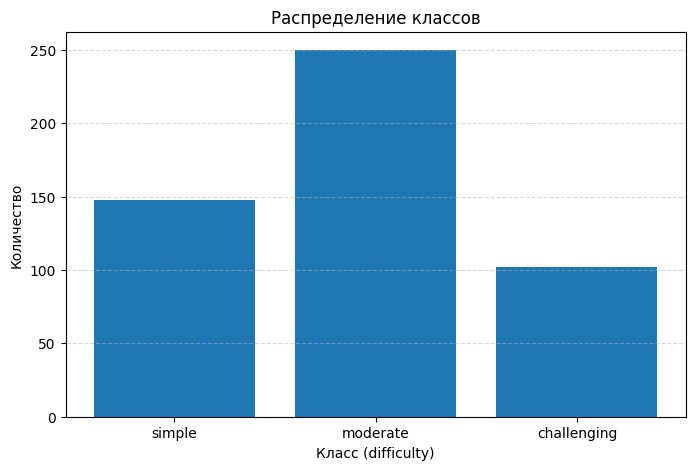

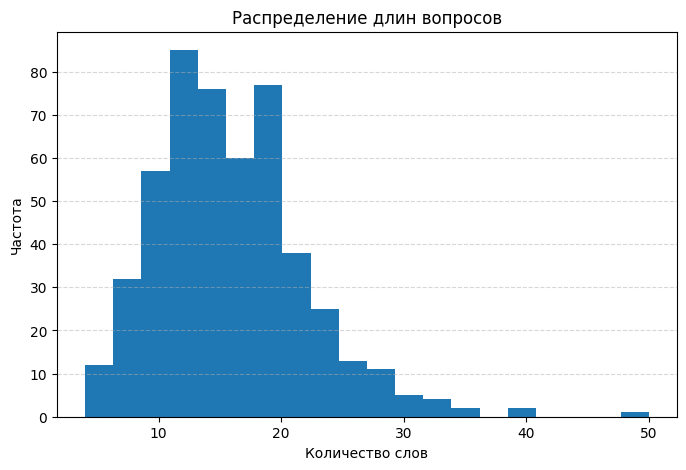

Количество объектов: 500
Средняя длина вопроса: 15.84 слов
Минимальная длина: 4 слов
Максимальная длина: 50 слов


In [3]:
# Загрузка данных
with open("dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# ==========================
# 1. Распределение классов
# ==========================
difficulties = [item["difficulty"] for item in data]
class_counts = Counter(difficulties)

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Распределение классов")
plt.xlabel("Класс (difficulty)")
plt.ylabel("Количество")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig("RaspredClasses.png")
plt.show()

# ==========================
# 2. Распределение длин текстов
# ==========================
# Длина вопроса в словах
question_lengths = [
    len(item["question"].split())
    for item in data
]

plt.figure(figsize=(8, 5))
plt.hist(question_lengths, bins=20)
plt.title("Распределение длин вопросов")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig("RaspredLengthQuestion.png")
plt.show()

# Базовая статистика
print(f"Количество объектов: {len(data)}")
print(f"Средняя длина вопроса: {sum(question_lengths)/len(question_lengths):.2f} слов")
print(f"Минимальная длина: {min(question_lengths)} слов")
print(f"Максимальная длина: {max(question_lengths)} слов")

In [ ]:
Количество объектов: 500
Средняя длина вопроса: 15.84 слов
Минимальная длина: 4 слов
Максимальная длина: 50 слов

In [ ]:
### Распределение классов (difficulty)
- Гистограмма показывает количество задач по категориям сложности (всего 500):
    - moderate — 250 (50.0%)
    - simple — 148 (29.6%)
    - challenging — 102 (20.4%)
- Распределение явно смещено в сторону «moderate» (доля moderate более чем вдвое выше, чем challenging).
- Вывод и рекомендации: заметный дисбаланс классов — при обучении моделей стоит учитывать это (взвешивание классов, ресэмплирование, стратификация при разбиении), а также отслеживать метрики по каждому классу (precision/recall/F1), а не только accuracy.

### Распределение длин вопросов
- Гистограмма частот длин вопросов (в словах) показывает, что большинство вопросов имеют длину примерно 8–20 слов, с пиком около 10–15 слов.
- Базовая статистика (вывод в ноутбуке): всего 500 объектов; средняя, минимальная и максимальная длина указаны в консольном выводе.